In [1]:
import sire
from os.path import abspath
import os
cs = sire.ControlServer.instance()
result = []
parameters = [[2e3, 0], [2e5, 0], [3e6, 0], [2e8, 0]]
sim_duration = 4
dt = 0.001
ctrlt = 10

for i in range(len(parameters)):
  sire.fromXmlFile(cs, abspath(os.getcwd()) + "/box.xml")
  cs.init()
  simulator = sire.simulator(cs)
  pe = cs.physicsEngine()
  simulator.simDuration = sim_duration
  simulator.deltaT = dt
  simulator.ctrlT = ctrlt
  contactPropStr = f"{{k:{parameters[i][0]},d:{parameters[i][1]},cof:0,threshold_velocity:1e-4}}"
  print(contactPropStr)
  pe.contactPositionForceSolver().addMaterialPair("steel", "copper", contactPropStr)
  while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
    simulator.step(1, False)
  model = cs.model()
  displayInitJson = model.displayInitJson()
  sim_result = simulator.recordsToJson()
  result.append([displayInitJson, sim_result])


{k:2000.0,d:0,cof:0,threshold_velocity:1e-4}
{k:200000.0,d:0,cof:0,threshold_velocity:1e-4}
{k:3000000.0,d:0,cof:0,threshold_velocity:1e-4}
{k:200000000.0,d:0,cof:0,threshold_velocity:1e-4}


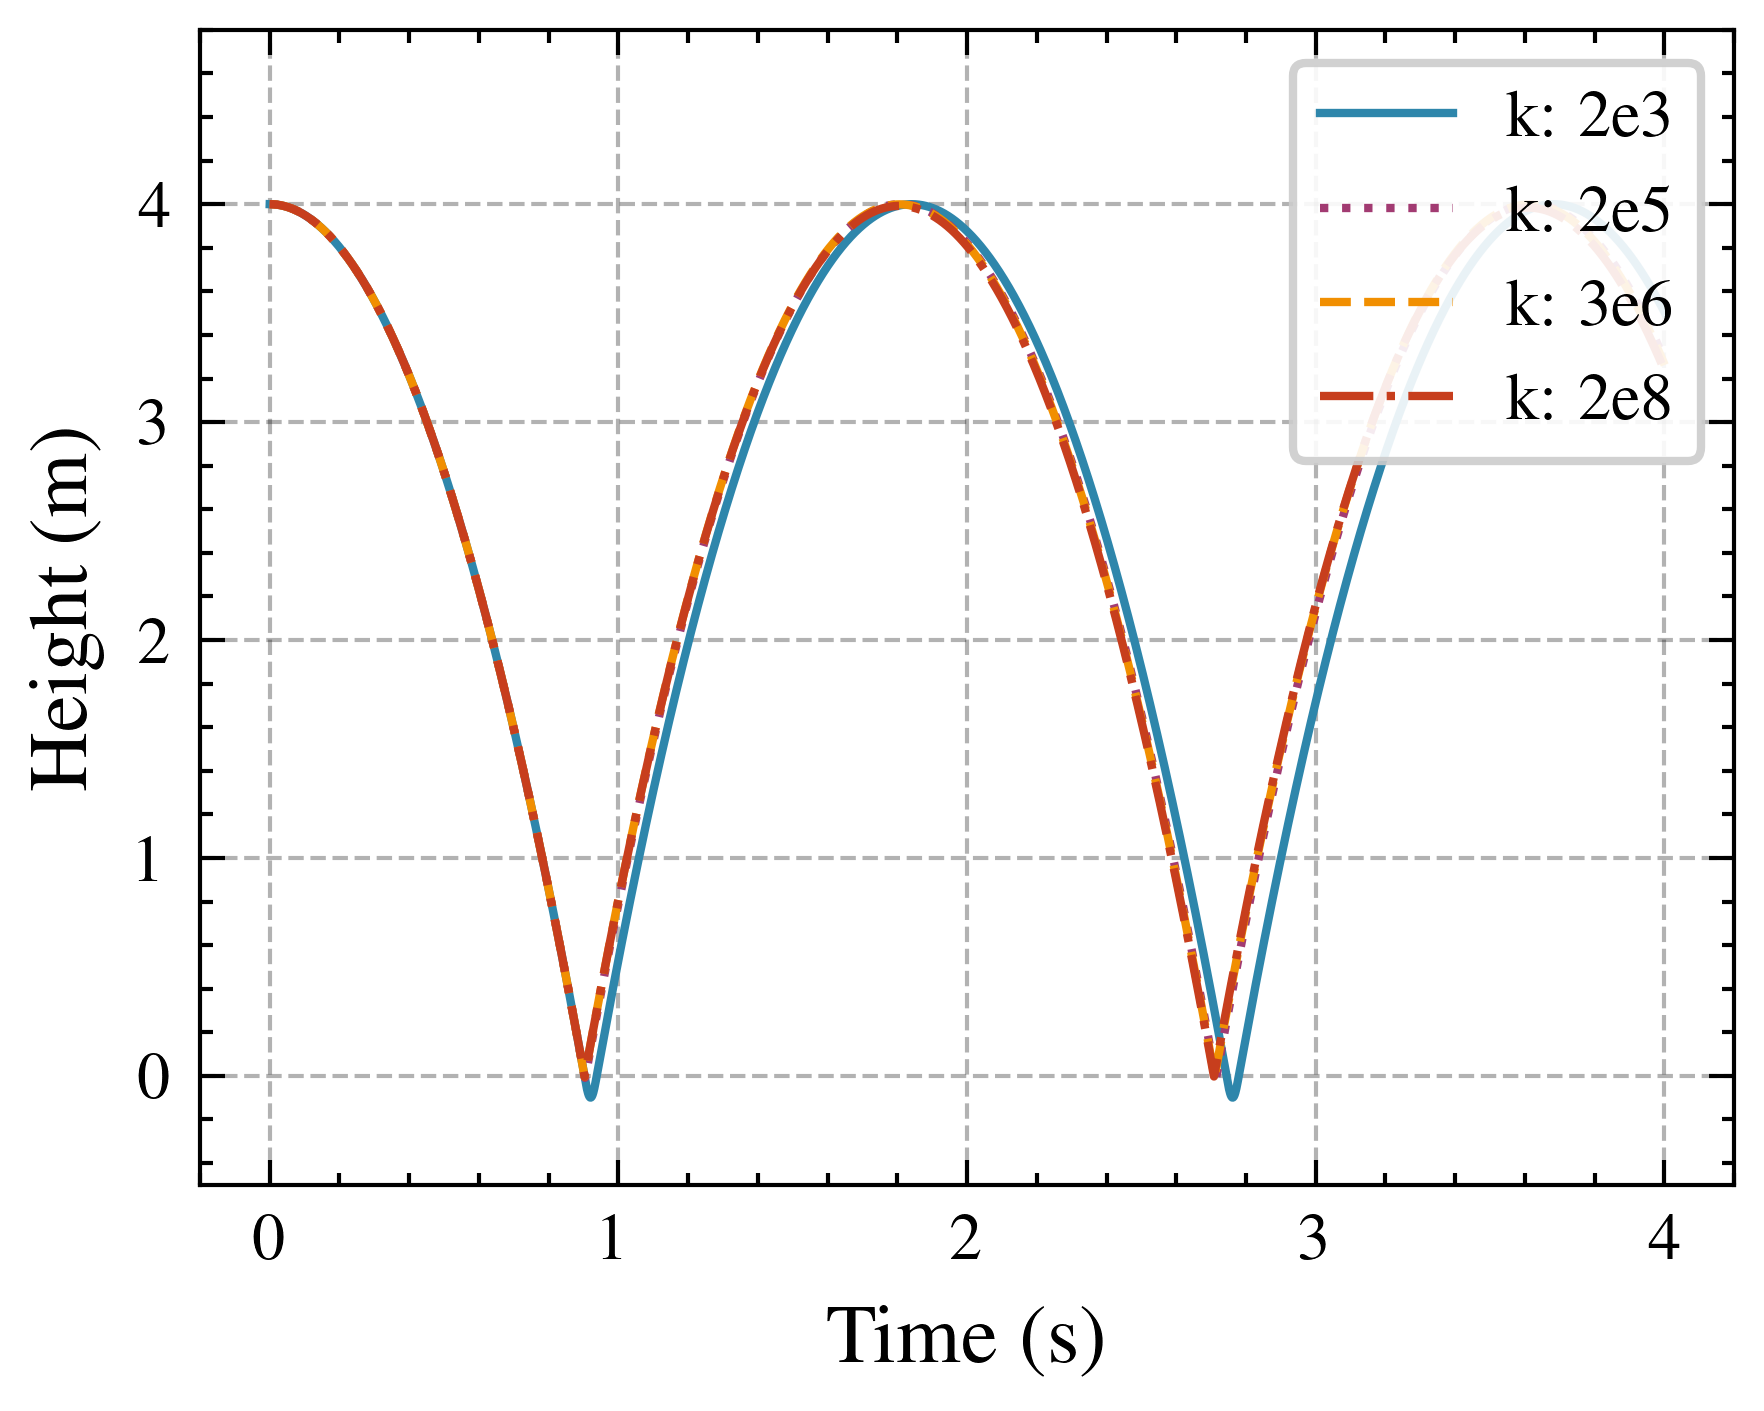

In [2]:
import matplotlib.pyplot as plt
import scienceplots
import numpy as np

def simple_sci_format(number):
    """最简单的科学计数法格式化"""
    sci_str = f"{number:.0e}"
    return sci_str.replace('+0', '').replace('+', '')

with plt.style.context(['science','ieee', 'grid']):
  legendStrs = []
  linestyles = ["-", ":", "--", "-."]
  scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
  ]
  for i in range(len(parameters)):
    pltResult = result[i][1]
    timeIndices = pltResult['timeIndex']
    contactInfo = pltResult["contactInfo"]
    partpq = pltResult["partPq"]
    partvs = pltResult["partVs"]
    partas = pltResult["partAs"]
    dts = pltResult["dts"]
    x = []
    y = []
    yv = []
    
    lowerBound = sire.binarySearch(timeIndices, 0)
    upperBound = sire.binarySearch(timeIndices, 10)
    
    for j in range(lowerBound, upperBound + 1):
      # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
      x.append(timeIndices[j])
      y.append(sire.pq2tfmatrix(partpq[j][1])[2, 3]-0.5)  # z position from transformation matrix
      yv.append(partvs[j][1][2])  # z velocity
    # .append(f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    # plt.plot(x, y, linewidth=1, label=f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    plt.plot(x, y, linewidth=1, label=f"k: {simple_sci_format(parameters[i][0])}", color=scientific_colors[i], linestyle=linestyles[i % 4])
  
  # plt.legend(loc="best", fontsize=8)
  plt.legend(framealpha=0.9, loc="upper right")
  plt.ylim(top=4.8, bottom=-0.5)
  plt.ylabel(r'Height (m)', fontsize=10)
  plt.xlabel(r'Time (s)', fontsize=10)
  # plt.title('Bouncing ball by proposed method')
  plt.grid(True, alpha=0.3)
  plt.savefig("D:/papers/sire_contact_model/res/box_free_fall_height_data_sire.pdf", format="pdf", dpi=600, bbox_inches='tight')
  plt.show()

## Performance Tests

### Duration 10s simulation profile without dissipation.

In [13]:
# test simulation time
import sire
from os.path import abspath
import os
import time
cs = sire.ControlServer.instance()
timeCostResult = []
parameters = [[2e3, 0], [2e5, 0], [3e6, 0], [2e8, 0]]
sim_duration = 10
dt = 0.001
ctrlt = 100
n = 40
timeCostResult = np.zeros([len(parameters), n])

for i in range(len(parameters)):
  # timeCost = 0
  for j in range(n):
    sire.fromXmlFile(cs, abspath(os.getcwd()) + "/box.xml")
    cs.init()
    simulator = sire.simulator(cs)
    pe = cs.physicsEngine()
    simulator.simDuration = sim_duration
    simulator.deltaT = dt
    simulator.ctrlT = ctrlt
    contactPropStr = f"{{k:{parameters[i][0]},d:{parameters[i][1]},cof:0,threshold_velocity:1e-4}}"
    # print(contactPropStr)
    pe.contactPositionForceSolver().addMaterialPair("steel", "copper", contactPropStr)
    start = time.perf_counter()
    while(not simulator.isTimeout()):
      simulator.step(1, False)
    end = time.perf_counter()
    elapsed = end - start
    timeCostResult[i][j] = elapsed
    # timeCost += elapsed
  # timeCostResult.append(timeCost)

# Save time cost data csv
np.savetxt(
    'sire_perf_measure_10s_zero_dissipation.csv',          # Filename
    timeCostResult.transpose(),  # Combine x and y into two columns
    delimiter=',',            # Use comma as delimiter
    comments=''               # Remove '#' from header
)

In [14]:
data = np.genfromtxt('sire_perf_measure_10s_zero_dissipation.csv', delimiter=',')

print(np.sum(data, 0) / data.shape[0])

[0.18106362 0.08823176 0.07579002 0.07630357]


### Duration 10s simulation profile with high dissipation.

In [16]:
# test simulation time
import sire
from os.path import abspath
import os
import time
cs = sire.ControlServer.instance()
timeCostResult = []
# parameters = [[2e3, 0], [2e5, 0], [3e6, 0], [2e8, 0]]
parameters = [[2e3, 1e5], [2e5, 1e5], [3e6, 1e5], [2e8, 1e5]]
sim_duration = 10
dt = 0.001
ctrlt = 100
n = 40
timeCostResult = np.zeros([len(parameters), n])

for i in range(len(parameters)):
  # timeCost = 0
  for j in range(n):
    print(i, j)
    sire.fromXmlFile(cs, abspath(os.getcwd()) + "/box.xml")
    cs.init()
    simulator = sire.simulator(cs)
    pe = cs.physicsEngine()
    simulator.simDuration = sim_duration
    simulator.deltaT = dt
    simulator.ctrlT = ctrlt
    contactPropStr = f"{{k:{parameters[i][0]},d:{parameters[i][1]},cof:0,threshold_velocity:1e-4}}"
    # print(contactPropStr)
    pe.contactPositionForceSolver().addMaterialPair("steel", "copper", contactPropStr)
    start = time.perf_counter()
    while(not simulator.isTimeout()):
      simulator.step(1, False)
    end = time.perf_counter()
    elapsed = end - start
    timeCostResult[i][j] = elapsed
    # timeCost += elapsed
  # timeCostResult.append(timeCost)

# Save time cost data csv
np.savetxt(
    'sire_perf_measure_10s_high_dissipation.csv',          # Filename
    timeCostResult.transpose(),  # Combine x and y into two columns
    delimiter=',',            # Use comma as delimiter
    comments=''               # Remove '#' from header
)

0 0
0 1
0 2


KeyboardInterrupt: 

In [ ]:
data = np.genfromtxt('sire_perf_measure_10s_high_dissipation.csv', delimiter=',')

print(np.sum(data, 0) / data.shape[0])

[0.17694286 0.07304355 0.0653611  0.06512058]


### Contact profile

In [20]:
# test simulation time
import sire
import numpy as np
from os.path import abspath
import os
import time
cs = sire.ControlServer.instance()
timeCostResult = []
# parameters = [[2e3, 1e5], [2e5, 1e5], [3e6, 1e5], [2e8, 1e5]]
parameters = [[2e3, 0], [2e5, 0], [3e6, 0], [2e8, 0]]
sim_duration = 10
dt = 0.001
ctrlt = 100
n = 1000
timeCostResult = np.zeros([len(parameters), n])

for i in range(len(parameters)):
  # timeCost = 0
  for j in range(n):
    sire.fromXmlFile(cs, abspath(os.getcwd()) + "/profile_contact.xml")
    cs.init()
    simulator = sire.simulator(cs)
    pe = cs.physicsEngine()
    contactPropStr = f"{{k:{parameters[i][0]},d:{parameters[i][1]},cof:0,threshold_velocity:1e-4}}"
    # print(contactPropStr)
    pe.contactPositionForceSolver().addMaterialPair("steel", "copper", contactPropStr)
    isCtrl = simulator.integrate()
    start = time.perf_counter()
    simulator.handleContact()
    end = time.perf_counter()
    elapsed = end - start
    timeCostResult[i][j] = elapsed
    # timeCost += elapsed
  # timeCostResult.append(timeCost)

# Save time cost data csv
np.savetxt(
    'sire_perf_measure_contact.csv',          # Filename
    timeCostResult.transpose(),  # Combine x and y into two columns
    delimiter=',',            # Use comma as delimiter
    comments=''               # Remove '#' from header
)

In [21]:
data = np.genfromtxt('sire_perf_measure_contact.csv', delimiter=',')

print(np.sum(data, 0) / data.shape[0])

[0.00083159 0.00091854 0.00082721 0.0007575 ]


## Parameter k Range Tests

In [9]:
import sire
from os.path import abspath
import os
import numpy as np
cs = sire.ControlServer.instance()
result = []
start = 200
end = 2e30
num_points = 1000  # 你需要的点数

# 最简单的方法
parameters = np.geomspace(start, end, num_points)
# parameters = [[2e2, 0], [2e30, 0]]
sim_duration = 2.2
dt = 0.001
ctrlt = 10

for i in range(len(parameters)):
  sire.fromXmlFile(cs, abspath(os.getcwd()) + "/box.xml")
  cs.init()
  simulator = sire.simulator(cs)
  pe = cs.physicsEngine()
  simulator.simDuration = sim_duration
  simulator.deltaT = dt
  simulator.ctrlT = ctrlt
  contactPropStr = f"{{k:{parameters[i]},d:0,cof:0,threshold_velocity:1e-4}}"
  # print(contactPropStr)
  pe.contactPositionForceSolver().addMaterialPair("steel", "copper", contactPropStr)
  while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
    simulator.step(1, False)
  model = cs.model()
  # displayInitJson = model.displayInitJson()
  sim_result = simulator.recordsToJson()
  # contact_solver_result = simulator.recordsContactCptInfo()
  result.append(sim_result)

heights = np.zeros(np.size(parameters))
for i in range(len(parameters)):
  pltResult = result[i]
  timeIndices = pltResult['timeIndex']
  partpq = pltResult["partPq"]
  
  lowerBound = 900
  upperBound = sire.binarySearch(timeIndices, 2.2)
  firstBounceHeight = 0
  for j in range(900, upperBound + 1):
    # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
    height = partpq[j][1][2]-0.5
    if height > firstBounceHeight:
       firstBounceHeight = height
  heights[i] = firstBounceHeight - 4

if len(heights) == len(parameters):
  # Save first bouncing height data csv
  np.savetxt(
      'first_bouncing_data.csv',          # Filename
      np.column_stack((parameters, heights)),  # Combine x and y into two columns
      delimiter=',',            # Use comma as delimiter
      header='stiffness,height',             # Column headers
      comments=''               # Remove '#' from header
  )

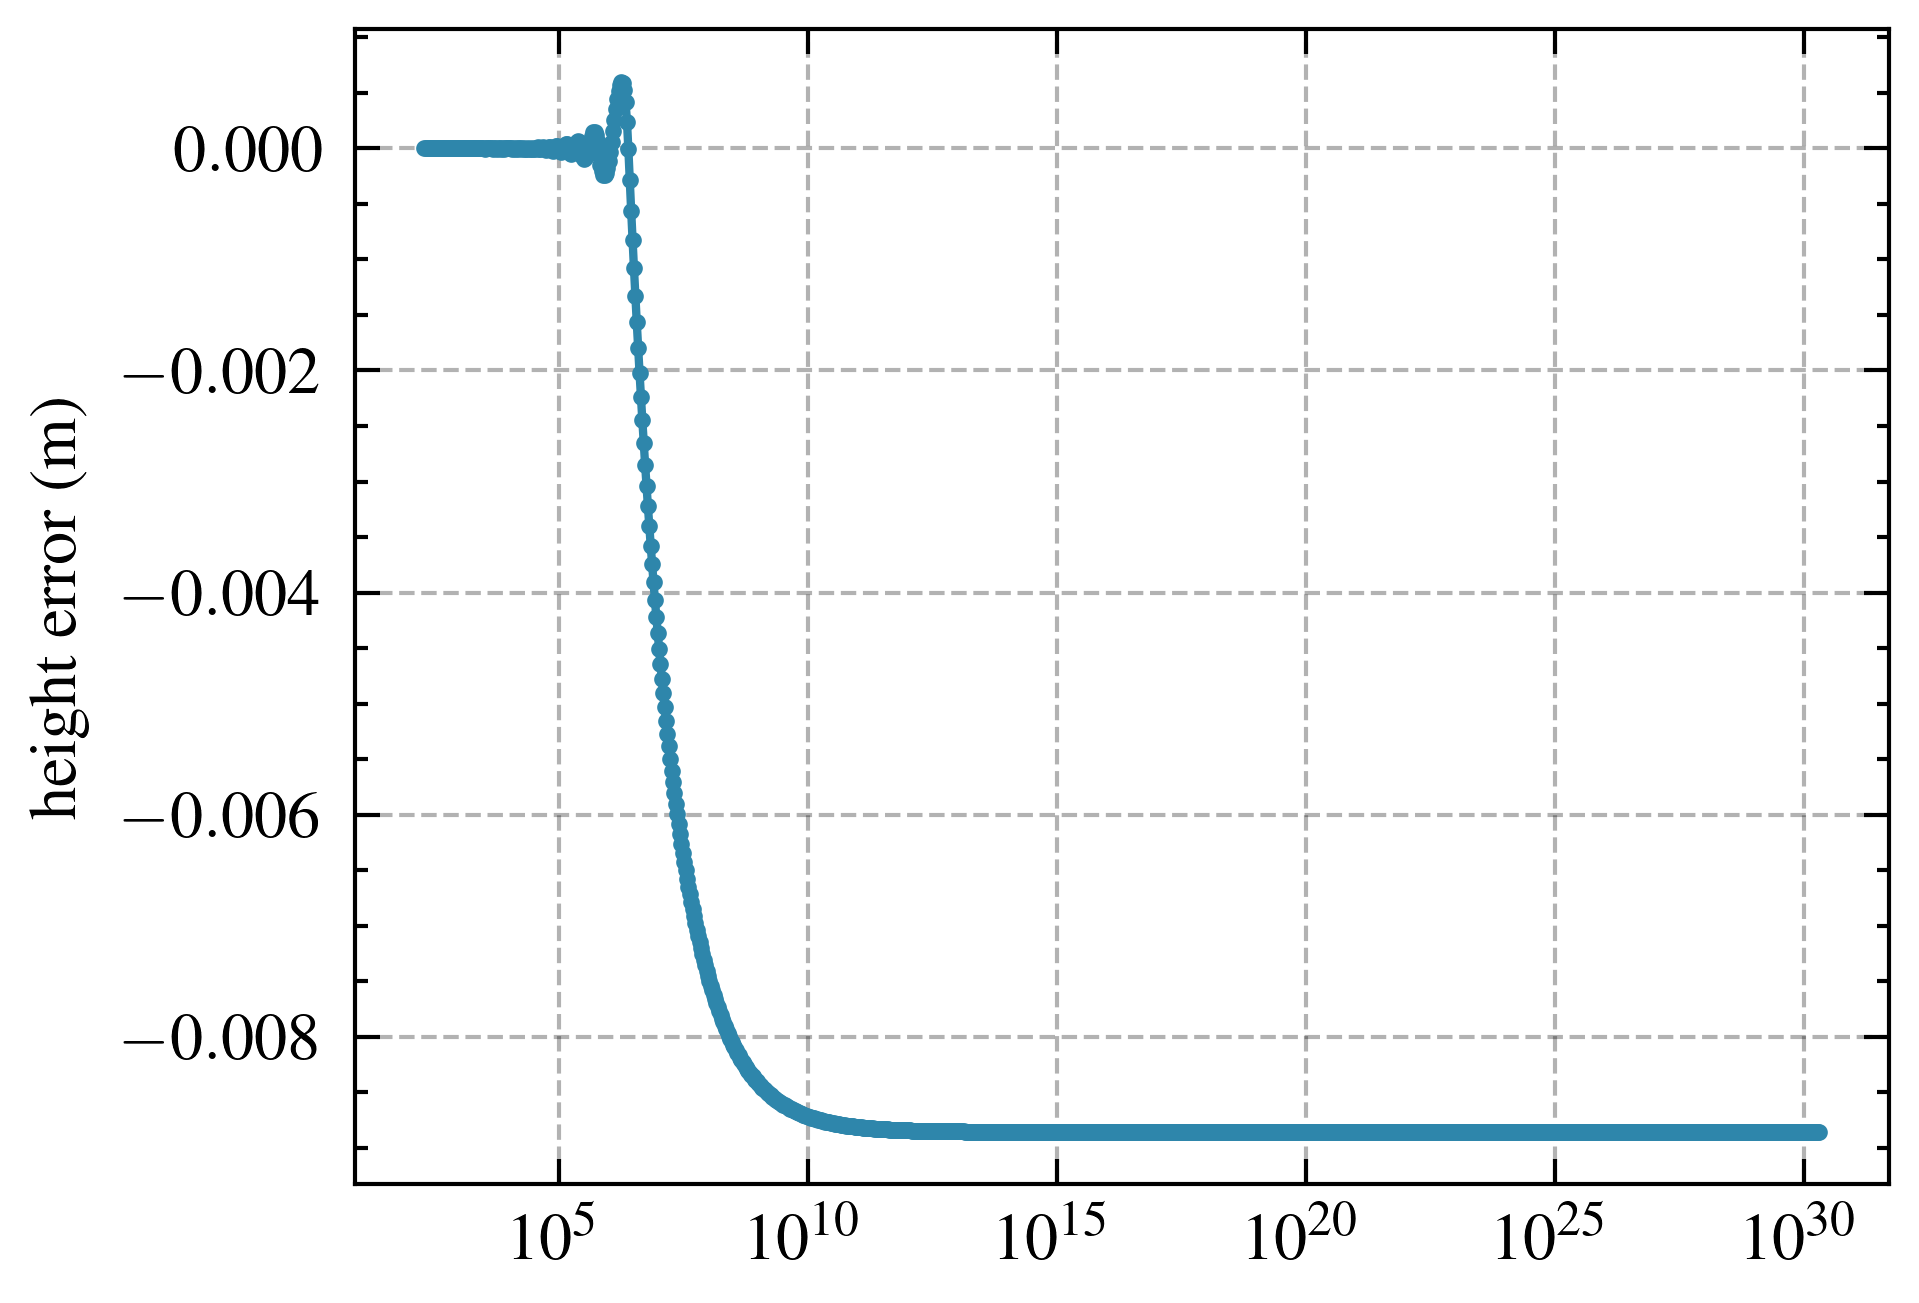

In [10]:
import matplotlib.pyplot as plt
import scienceplots
import numpy as np

def simple_sci_format(number):
    """最简单的科学计数法格式化"""
    sci_str = f"{number:.0e}"
    return sci_str.replace('+0', '').replace('+', '')


# print(np.where(heights > 1e4)[0][0])
with plt.style.context(['science','ieee', 'grid']):
  legendStrs = []
  linestyles = ["-", ":", "--", "-."]
  scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
  ]
  plt.semilogx(parameters, heights, marker='o', markersize=1, linewidth=1, color=scientific_colors[0])
  # plt.legend(loc="best", fontsize=8)
  # plt.legend(framealpha=0.9, loc="upper right")
  # plt.ylim(top=5.5, bottom=-0.5)
  plt.ylabel(r'height error (m)')
  plt.grid(True, linestyle='--', alpha=0.3)
  # plt.xlabel(r'Time (s)')
  # plt.title('Bouncing ball by proposed method')
  # plt.grid(True, alpha=0.3)
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire.pdf", format="pdf")
  plt.show()

In [3]:
from selenium import webdriver
import base64
import io
from PIL import Image
import meshcat
import numpy as np

import sire
from os.path import abspath
import os
cs = sire.ControlServer.instance()
result = []
parameters = [[2e3, 0], [2e5, 0], [3e6, 0], [2e8, 0]]
sim_duration = 4
dt = 0.001
ctrlt = 10

for i in range(len(parameters)):
  sire.fromXmlFile(cs, abspath(os.getcwd()) + "/box.xml")
  cs.init()
  simulator = sire.simulator(cs)
  pe = cs.physicsEngine()
  simulator.simDuration = sim_duration
  simulator.deltaT = dt
  simulator.ctrlT = ctrlt
  contactPropStr = f"{{k:{parameters[i][0]},d:0,cof:0,threshold_velocity:1e-4}}"
  print(contactPropStr)
  # print(contactPropStr)
  pe.contactPositionForceSolver().addMaterialPair("steel", "copper", contactPropStr)
  while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
    simulator.step(1, False)
  model = cs.model()
  displayInitJson = model.displayInitJson()
  sim_result = simulator.recordsToJson()
  # contact_solver_result = simulator.recordsContactCptInfo()
  result.append([sim_result, displayInitJson])

vis = meshcat.Visualizer()
heights = np.zeros(np.size(parameters))
for i in range(len(parameters)):
  pltResult = result[i][0]
  timeIndices = pltResult['timeIndex']
  partpq = pltResult["partPq"]
  resourcePath = "D:/code/sire/demo/demo_python/dogRL"
  sire.robotInit(model.numLinks(), resourcePath, result[i][1], vis)
  lowerBound = 900
  upperBound = sire.binarySearch(timeIndices, 2.2)
  firstBounceHeight = 0
  for j in range(900, upperBound + 1):
    # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
    heights[i] = partpq[j][1][2]-0.5
    if heights[i] > firstBounceHeight:
      firstBounceHeight = heights[i]
      maxIndex = j
  heights[i] = firstBounceHeight - 4
  sire.setRobotPq(model.numLinks(), vis, partpq[maxIndex])
  print(maxIndex, firstBounceHeight, partpq[maxIndex][1][2])
  # vis.set_cam_pos([5, 0, 6])
  # vis.set_cam_target([10, 0, 10])
  
  vis["/Cameras/default"].set_transform(np.eye(4))
  vis.set_cam_pos([8, 0, 2])
  # vis.set_cam_target([0.5, 1., -0.5])
  # img = vis.get_image()
  # cropped_img = img.crop((1000, 0, 1500, 800))
  # cropped_img
  # Set up Chrome options to run in headless mode
  chrome_options = webdriver.ChromeOptions()
  chrome_options.add_argument('--headless')
  chrome_options.add_argument("--window-size=1920,1080")
  # chrome_options.add_argument('--no-sandbox')
  # chrome_options.add_argument('--disable-dev-shm-usage')

  # Initialize the Chrome WebDriver 
  driver = webdriver.Chrome(chrome_options)

  # Open the Meshcat viewer's URL
  driver.get(vis.url())
  image_data_url = driver.execute_script("""
      return viewer.capture_image(200, 100);  // Capture the image with width and height
  """)
  # Extract the base64 part of the data URL (after "data:image/png;base64,")
  image_base64 = image_data_url.split(",")[1]

  # Decode the base64 string and save it as an image file
  image_data = base64.b64decode(image_base64)
  # Write the image to a file
  image = Image.open(io.BytesIO(image_data))
  print(image._size)
  cropped_img = image.crop((700, 0, 1200, 600))

  # cropped_img = image.crop((700, 0, 1200, 800))
  cropped_img.save(f"./pic/{parameters[i][0]}.png")
  # with open(f"./test_data/{parameters[i][0]}.png", "wb+") as f:
  #     f.write(image_data)

  # Close the browser session
  driver.quit()

{k:2000.0,d:0,cof:0,threshold_velocity:1e-4}
{k:200000.0,d:0,cof:0,threshold_velocity:1e-4}
{k:3000000.0,d:0,cof:0,threshold_velocity:1e-4}
{k:200000000.0,d:0,cof:0,threshold_velocity:1e-4}
You can open the visualizer by visiting the following URL:
http://127.0.0.1:7018/static/
1841 4.0000014594364295 4.5000014594364295
(1902, 932)
1810 3.999996662234886 4.499996662234886
(1902, 932)
1807 3.9991769123509604 4.49917691235096
(1902, 932)
1807 3.992125518712638 4.492125518712638
(1902, 932)
